<a href="https://colab.research.google.com/github/AbnerJSV/THE_CORE_Trabajos_iA/blob/main/Reto_evaluable_PRO.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [3]:
# Configuración inicial
import tensorflow as tf
import tensorflow_datasets as tfds
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

SEED = 42
tf.random.set_seed(SEED)
np.random.seed(SEED)

IMG_SIZE = 160
BATCH_SIZE = 32
AUTOTUNE = tf.data.AUTOTUNE

In [4]:
# Cargar Oxford-IIIT Pet desde tensorflow_datasets
(ds_train_raw, ds_test_raw), ds_info = tfds.load(
    "oxford_iiit_pet",
    split=["train[:80%]", "train[80%:]"],
    with_info=True,
    as_supervised=True
)

label_names = ds_info.features["label"].names
num_classes = ds_info.features["label"].num_classes

print("Número de clases:", num_classes)
print("Ejemplo de etiquetas:", label_names[:10])

Número de clases: 37
Ejemplo de etiquetas: ['Abyssinian', 'american_bulldog', 'american_pit_bull_terrier', 'basset_hound', 'beagle', 'Bengal', 'Birman', 'Bombay', 'boxer', 'British_Shorthair']


In [5]:
# Elegir la función preprocess_input según la arquitectura que vayamos a usar.
# Para MobileNetV2:
preprocess_input_mobilenet = tf.keras.applications.mobilenet_v2.preprocess_input
# Para EfficientNetB0:
preprocess_input_efficientnet = tf.keras.applications.efficientnet.preprocess_input

# Aquí usamos MobileNetV2 preprocess por defecto; cambia si usas EfficientNetB0.
preprocess_input = preprocess_input_mobilenet

def preprocess(image, label):
    image = tf.image.resize(image, (IMG_SIZE, IMG_SIZE))
    image = tf.cast(image, tf.float32)
    image = preprocess_input(image)
    return image, label

train_ds = (
    ds_train_raw
    .shuffle(2000, seed=SEED)
    .map(preprocess, num_parallel_calls=AUTOTUNE)
    .batch(BATCH_SIZE)
    .prefetch(AUTOTUNE)
)

test_ds = (
    ds_test_raw
    .map(preprocess, num_parallel_calls=AUTOTUNE)
    .batch(BATCH_SIZE)
    .prefetch(AUTOTUNE)
)

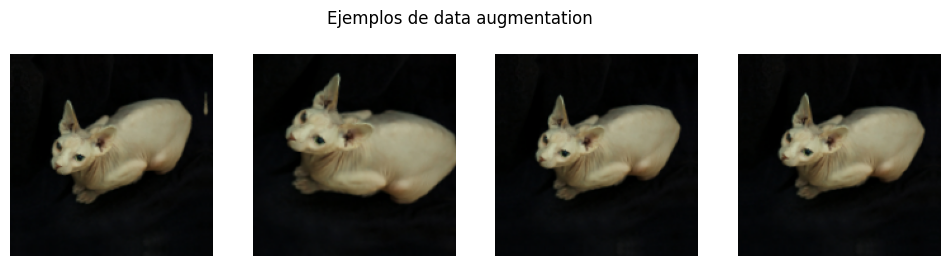

In [6]:
data_augmentation = tf.keras.Sequential([
    tf.keras.layers.RandomFlip("horizontal"),
    tf.keras.layers.RandomRotation(0.05),
    tf.keras.layers.RandomZoom(0.1),
], name="data_augmentation")

# Visualizar augmentations (opcional)
for image, label in ds_train_raw.take(1):
    img = tf.image.resize(image, (IMG_SIZE, IMG_SIZE))
    plt.figure(figsize=(12,3))
    for i in range(4):
        aug = data_augmentation(tf.expand_dims(img, 0), training=True)
        plt.subplot(1,4,i+1)
        plt.imshow(tf.cast(aug[0], tf.uint8))
        plt.axis("off")
    plt.suptitle("Ejemplos de data augmentation")
    plt.show()

In [7]:
def build_model(base_model, num_classes, data_augmentation):
    base_model.trainable = False
    inputs = tf.keras.Input(shape=(IMG_SIZE, IMG_SIZE, 3))
    x = data_augmentation(inputs)
    x = base_model(x, training=False)
    x = tf.keras.layers.GlobalAveragePooling2D()(x)
    x = tf.keras.layers.Dropout(0.2)(x)
    outputs = tf.keras.layers.Dense(num_classes, activation="softmax")(x)
    model = tf.keras.Model(inputs, outputs)
    return model

def compile_and_train(model, train_ds, val_ds, lr, epochs, callbacks=None, initial_epoch=0):
    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=lr),
        loss="sparse_categorical_crossentropy",
        metrics=["accuracy"]
    )
    history = model.fit(
        train_ds,
        validation_data=val_ds,
        epochs=epochs,
        initial_epoch=initial_epoch,
        callbacks=callbacks
    )
    return history

def evaluate_and_report(model, test_ds):
    loss, acc = model.evaluate(test_ds, verbose=0)
    print(f"Test loss: {loss:.4f}  Test accuracy: {acc:.4f}")
    return loss, acc

In [8]:
# Callbacks comunes
callbacks = [
    tf.keras.callbacks.EarlyStopping(monitor="val_accuracy", patience=3, restore_best_weights=True)
]

results = {}

# Arquitectura A: MobileNetV2
base_mobilenet = tf.keras.applications.MobileNetV2(
    input_shape=(IMG_SIZE, IMG_SIZE, 3),
    include_top=False,
    weights="imagenet"
)
model_mobilenet = build_model(base_mobilenet, num_classes, data_augmentation)
print("Resumen MobileNetV2 (fase 1)")
model_mobilenet.summary()

# Fase 1: feature extraction
history_mn_1 = compile_and_train(model_mobilenet, train_ds, test_ds, lr=1e-3, epochs=6, callbacks=callbacks)
# Fine-tuning: descongelar parte de la base
base_mobilenet.trainable = True
# Ajusta fine_tune_at según experimentos; MobileNetV2 tiene ~155 capas
fine_tune_at_mn = 100
for layer in base_mobilenet.layers[:fine_tune_at_mn]:
    layer.trainable = False

history_mn_2 = compile_and_train(model_mobilenet, train_ds, test_ds, lr=1e-5, epochs=10, callbacks=callbacks, initial_epoch=history_mn_1.epoch[-1] + 1)
loss_mn, acc_mn = evaluate_and_report(model_mobilenet, test_ds)
results['MobileNetV2'] = {'history1': history_mn_1, 'history2': history_mn_2, 'test_loss': loss_mn, 'test_acc': acc_mn, 'fine_tune_at': fine_tune_at_mn}

# Arquitectura B: EfficientNetB0
base_efficient = tf.keras.applications.EfficientNetB0(
    input_shape=(IMG_SIZE, IMG_SIZE, 3),
    include_top=False,
    weights="imagenet"
)
# Cambiar preprocess_input para EfficientNet si se usa desde el inicio
preprocess_input = preprocess_input_efficientnet

# Reconstruir pipelines si se desea usar otro preprocess_input (opcional)
# Para simplicidad, asumimos que el pipeline anterior es aceptable; en práctica, re-mapear con el nuevo preprocess_input.

model_efficient = build_model(base_efficient, num_classes, data_augmentation)
print("Resumen EfficientNetB0 (fase 1)")
model_efficient.summary()

# Fase 1: feature extraction
history_en_1 = compile_and_train(model_efficient, train_ds, test_ds, lr=1e-3, epochs=6, callbacks=callbacks)
# Fine-tuning
base_efficient.trainable = True
# EfficientNetB0 tiene ~237 capas; ajustamos corte
fine_tune_at_en = 150
for layer in base_efficient.layers[:fine_tune_at_en]:
    layer.trainable = False

history_en_2 = compile_and_train(model_efficient, train_ds, test_ds, lr=1e-5, epochs=10, callbacks=callbacks, initial_epoch=history_en_1.epoch[-1] + 1)
loss_en, acc_en = evaluate_and_report(model_efficient, test_ds)
results['EfficientNetB0'] = {'history1': history_en_1, 'history2': history_en_2, 'test_loss': loss_en, 'test_acc': acc_en, 'fine_tune_at': fine_tune_at_en}

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step
Resumen MobileNetV2 (fase 1)


Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_2 (InputLayer)      │ (None, 160, 160, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ data_augmentation (Sequential)  │ (None, 160, 160, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_1.00_160            │ (None, 5, 5, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 37)             │        47,397 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,305,381 (8.79 MB)

 Trainable params: 47,397 (185.14 KB)

...

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_4 (InputLayer)      │ (None, 160, 160, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ data_augmentation (Sequential)  │ (None, 160, 160, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ efficientnetb0 (Functional)     │ (None, 5, 5, 1280)     │     4,049,571 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_1      │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 37)             │        47,397 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,096,968 (15.63 MB)

 Trainable params: 47,397 (185.14 KB)

 Non-trainable params: 4,049,571 (15.45 MB)

Epoch 1/6
92/92 ━━━━━━━━━━━━━━━━━━━━ 169s 2s/step - accuracy: 0.0275 - loss: 3.6773 - val_accuracy: 0.0190 - val_loss: 3.6531
Epoch 2/6
92/92 ━━━━━━━━━━━━━━━━━━━━ 174s 2s/step - accuracy: 0.0309 - loss: 3.6785 - val_accuracy: 0.0245 - val_loss: 3.6746
Epoch 3/6
92/92 ━━━━━━━━━━━━━━━━━━━━ 166s 2s/step - accuracy: 0.0211 - loss: 3.6749 - val_accuracy: 0.0231 - val_loss: 3.6743
Epoch 4/10
92/92 ━━━━━━━━━━━━━━━━━━━━ 247s 2s/step - accuracy: 0.0326 - loss: 3.7061 - val_accuracy: 0.0190 - val_loss: 3.6308
Epoch 5/10
92/92 ━━━━━━━━━━━━━━━━━━━━ 260s 2s/step - accuracy: 0.0268 - loss: 3.6991 - val_accuracy: 0.0190 - val_loss: 3.6306
Epoch 6/10
92/92 ━━━━━━━━━━━━━━━━━━━━ 218s 2s/step - accuracy: 0.0326 - loss: 3.6576 - val_accuracy: 0.0231 - val_loss: 3.6403
Test loss: 3.6308  Test accuracy: 0.0190


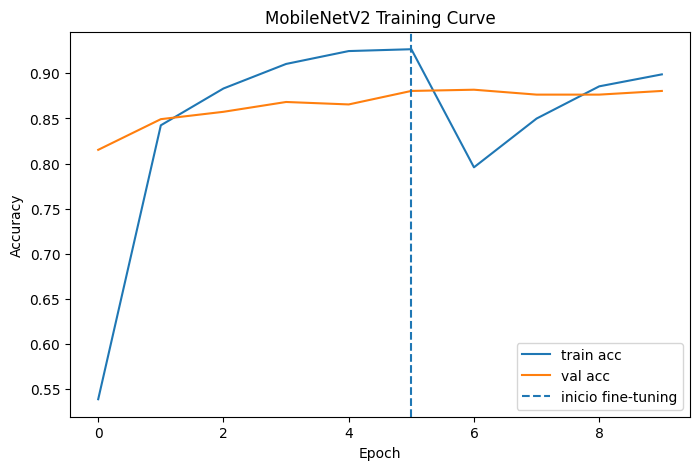

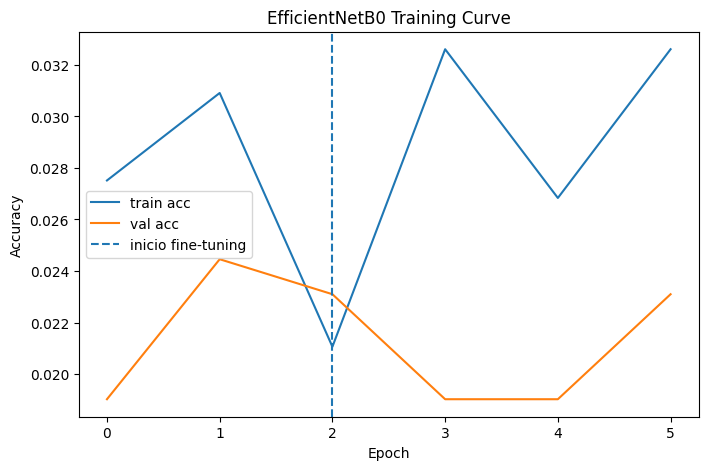

In [9]:
def plot_combined(history1, history2, title):
    acc = history1.history["accuracy"] + history2.history["accuracy"]
    val_acc = history1.history["val_accuracy"] + history2.history["val_accuracy"]
    plt.figure(figsize=(8,5))
    plt.plot(acc, label="train acc")
    plt.plot(val_acc, label="val acc")
    plt.axvline(x=len(history1.history["accuracy"])-1, linestyle="--", label="inicio fine-tuning")
    plt.xlabel("Epoch")
    plt.ylabel("Accuracy")
    plt.title(title)
    plt.legend()
    plt.show()

plot_combined(history_mn_1, history_mn_2, "MobileNetV2 Training Curve")
plot_combined(history_en_1, history_en_2, "EfficientNetB0 Training Curve")

Mejor modelo: MobileNetV2 Accuracy: 0.8817934989929199


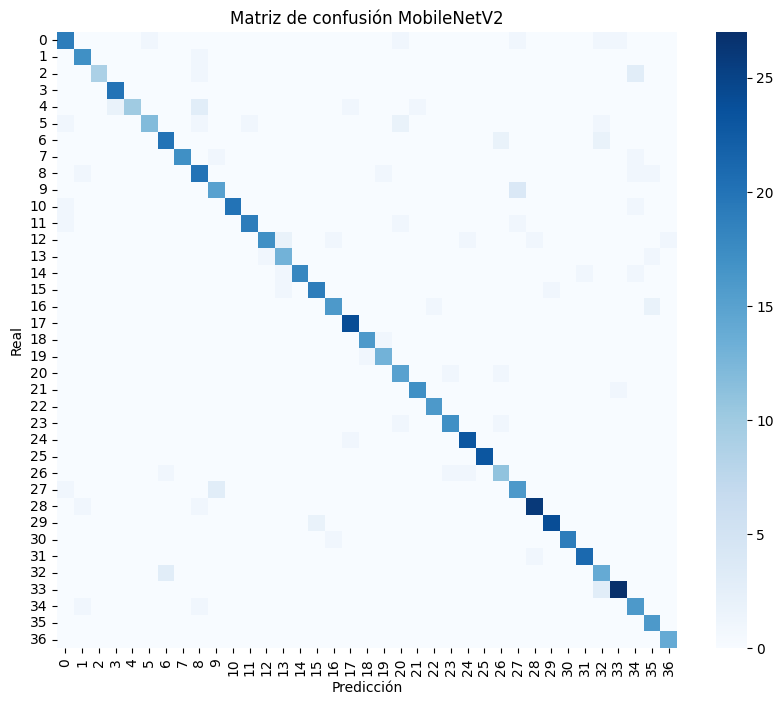

                            precision    recall  f1-score   support

                Abyssinian       0.83      0.79      0.81        24
          american_bulldog       0.85      0.94      0.89        18
 american_pit_bull_terrier       1.00      0.69      0.82        13
              basset_hound       0.91      1.00      0.95        20
                    beagle       1.00      0.59      0.74        17
                    Bengal       0.92      0.67      0.77        18
                    Birman       0.83      0.83      0.83        24
                    Bombay       1.00      0.89      0.94        19
                     boxer       0.71      0.83      0.77        24
         British_Shorthair       0.79      0.79      0.79        19
                 chihuahua       1.00      0.91      0.95        22
              Egyptian_Mau       0.95      0.86      0.90        22
    english_cocker_spaniel       0.94      0.74      0.83        23
            english_setter       0.76      0.87

In [10]:
# Elegimos el mejor modelo según test accuracy
best_model_name = max(results.keys(), key=lambda k: results[k]['test_acc'])
print("Mejor modelo:", best_model_name, "Accuracy:", results[best_model_name]['test_acc'])

best_model = model_mobilenet if best_model_name == 'MobileNetV2' else model_efficient

# Predicciones sobre test set
all_preds = []
all_true = []
for images, labels in test_ds:
    preds = best_model.predict(images, verbose=0)
    all_preds.append(np.argmax(preds, axis=1))
    all_true.append(labels.numpy())

all_preds = np.concatenate(all_preds)
all_true = np.concatenate(all_true)

# Matriz de confusión
from sklearn.metrics import confusion_matrix, classification_report
cm = confusion_matrix(all_true, all_preds, labels=range(num_classes))

plt.figure(figsize=(10,8))
sns.heatmap(cm, cmap="Blues", cbar=True)
plt.title(f"Matriz de confusión {best_model_name}")
plt.xlabel("Predicción")
plt.ylabel("Real")
plt.show()

# Reporte de clasificación (por si quieres incluir en el notebook)
print(classification_report(all_true, all_preds, target_names=label_names, zero_division=0))

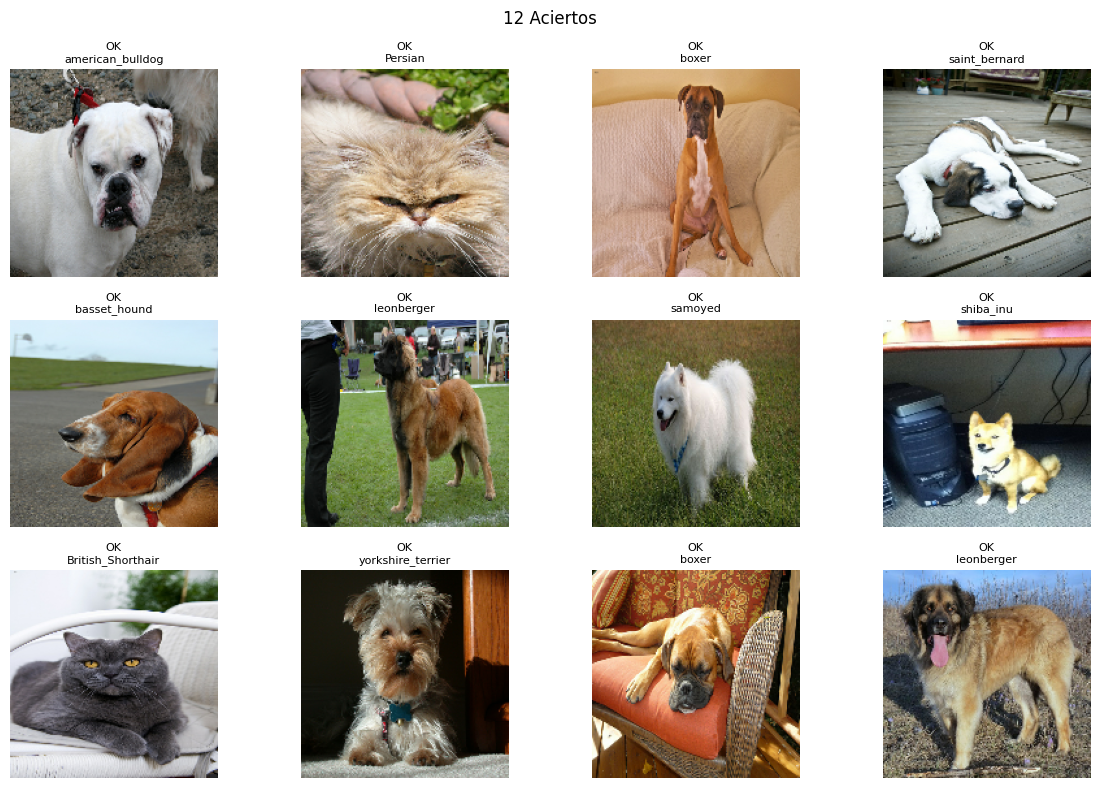

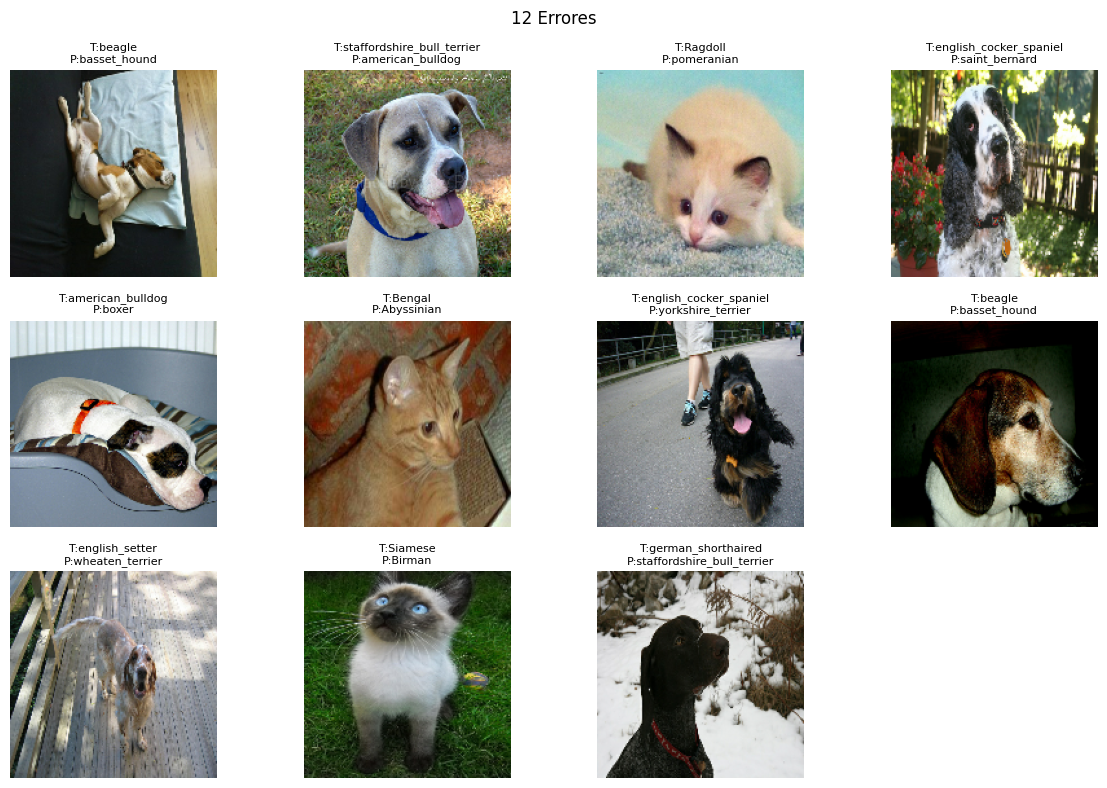

In [11]:
# Aciertos y errores: tomar una muestra del test para visualizar
sample_images = []
sample_labels = []
for images, labels in test_ds.take(3):
    sample_images.append(images)
    sample_labels.append(labels)

sample_images = tf.concat(sample_images, axis=0)
sample_labels = tf.concat(sample_labels, axis=0)

preds = best_model.predict(sample_images, verbose=0)
pred_classes = np.argmax(preds, axis=1)

correct = np.where(pred_classes == sample_labels.numpy())[0]
wrong = np.where(pred_classes != sample_labels.numpy())[0]

# Mostrar 12 aciertos
plt.figure(figsize=(12,8))
for i, idx in enumerate(correct[:12]):
    plt.subplot(3,4,i+1)
    img = sample_images[idx].numpy()
    # Si el preprocess_input cambió el rango, normalizamos para visualizar
    img_vis = (img - img.min()) / (img.max() - img.min())
    plt.imshow(np.clip(img_vis,0,1))
    plt.title(f"OK\n{label_names[int(pred_classes[idx])]}", fontsize=8)
    plt.axis("off")
plt.suptitle("12 Aciertos")
plt.tight_layout()
plt.show()

# Mostrar 12 errores
plt.figure(figsize=(12,8))
for i, idx in enumerate(wrong[:12]):
    plt.subplot(3,4,i+1)
    img = sample_images[idx].numpy()
    img_vis = (img - img.min()) / (img.max() - img.min())
    plt.imshow(np.clip(img_vis,0,1))
    t = label_names[int(sample_labels[idx])]
    p = label_names[int(pred_classes[idx])]
    plt.title(f"T:{t}\nP:{p}", fontsize=8)
    plt.axis("off")
plt.suptitle("12 Errores")
plt.tight_layout()
plt.show()

In [12]:
# Guardar el mejor modelo con nombre identificador
save_name = f"semana3_pro_abner_{best_model_name}.keras"
best_model.save(save_name)
print("Modelo guardado como:", save_name)

Modelo guardado como: semana3_pro_abner_MobileNetV2.keras


¿Por qué esta técnica es más realista que entrenar una CNN grande desde cero?

- Datos limitados: la mayoría de proyectos prácticos no dispone de millones de imágenes; entrenar desde cero con pocos datos conduce a sobreajuste.
- Coste computacional: entrenar una red profunda desde cero requiere mucho tiempo y recursos GPU; transfer learning reduce drásticamente ese coste.
- Reutilización de features: las primeras capas de modelos preentrenados ya capturan bordes, texturas y formas útiles para muchas tareas; aprovecharlas acelera la convergencia.
- Práctica industrial: en producción y en estudios de videojuegos se prefiere adaptar modelos preentrenados porque es más rápido, reproducible y robusto.


¿Qué errores comete tu modelo y por qué?

- Confusiones entre clases visualmente similares: razas o animales con coloración y forma parecida comparten features de alto nivel, por eso se confunden.
- Sensibilidad a fondo e iluminación: el modelo a veces aprende correlaciones con el contexto (fondo, iluminación) en lugar del objeto principal.
- Pocas muestras por clase: clases con pocas imágenes generan representaciones débiles y mayor varianza en la predicción.
- Imágenes atípicas: poses raras, occlusiones o baja calidad provocan errores porque no están bien representadas en el entrenamiento.


¿Qué adaptarías para trabajar con sprites o criaturas 2D?

- Dominio distinto: pixel art y sprites tienen texturas, contornos y paletas muy diferentes a fotos; el preprocesado y augmentations deben adaptarse.
- Augmentations específicos: usar traslaciones discretas, flips, escalados por pasos, jitter de color y paleta, evitar blur o rotaciones fuertes que destruyan píxeles.
- Modelos para baja resolución: considerar arquitecturas diseñadas para imágenes pequeñas o reducir la interpolación al reescalar sprites (evitar suavizado).
- Más fine‑tuning: descongelar más capas o reentrenar desde cero si se dispone de muchos sprites por clase; o usar preentrenamiento en datasets de arte si existe.


¿Qué ventaja viste en usar transfer learning frente a entrenar desde cero?

- Rápida mejora inicial: con feature extraction se obtiene rendimiento útil en pocas épocas.
- Menor necesidad de datos: el modelo aprovecha conocimiento previo y requiere menos ejemplos por clase para generalizar.
- Menor coste y tiempo: reduce horas/días de entrenamiento y facilita iterar experimentos (hiperparámetros, augmentations).
- Mejor reproducibilidad: usar pesos preentrenados estandariza el punto de partida entre experimentos y equipos.


¿Qué diferencia observaste entre feature extraction y fine-tuning?

- Feature extraction: se entrena solo la cabeza; aporta estabilidad y evita sobreajuste rápido; ideal para obtener una baseline sólida.
- Fine‑tuning: al descongelar capas profundas y usar un LR pequeño, el modelo adapta filtros a rasgos específicos del dominio y suele mejorar la accuracy en clases difíciles.
- Riesgo y beneficio: fine‑tuning puede aumentar la performance pero también el riesgo de sobreajuste si se descongelan demasiadas capas o el LR es alto; por eso se recomienda descongelar gradualmente y monitorizar val_loss.


¿Qué limitaciones tendría este modelo si lo aplicas a sprites, enemigos o criaturas de un videojuego real?

- Desajuste de dominio: modelos preentrenados en fotos no capturan bien estilos artísticos, sprites o renders estilizados.
- Resolución y escala: sprites pequeños pierden información al reescalar a tamaños grandes requeridos por muchas arquitecturas.
- Variabilidad de assets: en juegos, un mismo personaje puede tener múltiples skins, animaciones y efectos; el modelo necesita ver esa variabilidad.
- Requisitos de latencia: en tiempo real puede ser necesario un modelo mucho más ligero o cuantizado para cumplir restricciones de rendimiento.


¿Qué harías para adaptar este enfoque a personajes 2D?

- Recolectar y etiquetar más datos por clase: ampliar el dataset con variantes de pose, skins y fondos para reducir sesgos.
- Augmentations diseñadas para pixel art: traslaciones discretas, escalados por enteros, paleta jitter, flips y recortes que respeten píxeles.
- Probar arquitecturas para baja resolución: redes pequeñas inspiradas en CIFAR o MobileNetV3 Small; evaluar modelos entrenados en datasets de arte si existen.
- Aumentar fine‑tuning: descongelar más capas y usar validación para elegir fine_tune_at; experimentar con LR schedulers y regularización.
- Optimización para despliegue: cuantización, pruning y exportación a formatos eficientes para runtime en motor de juego.
- Evaluación cualitativa con diseñadores: integrar feedback humano para detectar confusiones relevantes para gameplay y ajustar clases o etiquetas.

